## Credit Card Transactions — Exploratory Data Analysis
**Author:** Rose Fidalgo Amorim  
**Dataset:** 50,000 credit card transactions (sample from 1.85M rows)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Objective:** Analyse consumer spending behaviour across categories, demographics and time patterns.

## 1- Data Loading & Exploration

In [29]:
# importer pandas permet de lire un dataframe : as pd est un raccourci
import pandas as pd
# importes les librairies de visualisation. Matplotlib est la base (graphiques simples)
import matplotlib.pyplot as plt
# Seaborn construit sur matplotlib et produit des graphiques plus beaux automatiquement
import seaborn as sns

sns.set_style("whitegrid") #dit a seaborn de construire sur un fond blanc
plt.rcParams['figure.figsize'] = (10, 5) #fichier de réglages global de Matplotlib. 10cm large et 5 de haut

# Charger le dataset
df = pd.read_csv("credit_card_transactions.csv")

# 1.85M lignes — on prend un échantillon reproductible de 50 000 lignes
# random_state=42 = toujours les mêmes 50 000 lignes 
#reset_index(drop=True) = permet de remettre dans l'ordre les données (0,1,2,..)
df = df.sample(50000, random_state=42).reset_index(drop=True)

print("Dimensions :", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())

df.head()

Dimensions : (50000, 24)

Colonnes disponibles :
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0
1,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0
3,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,...,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN
4,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0


We want the number of missing values per columns and the number of duplicate

In [30]:
print("Missing values per columns:")
valeurs_nulles = df.isnull().sum()[df.isnull().sum()>0]
print(valeurs_nulles)
print("Number of duplicate:", df.duplicated().sum())

Missing values per columns:
merch_zipcode    7533
dtype: int64
Number of duplicate: 0


## 2-  Data Cleaning

In [31]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time']) #converti en date
df['hour']=df['trans_date_trans_time'].dt.hour #extraire l'heure + créer une nouvelle colonne avec seulement l'heure
df['day_of_week']=df['trans_date_trans_time'].dt.day_name() #extraire le jour de la semaine dans une nouvelle colonne
print(df[['trans_date_trans_time','hour','day_of_week']].head())

  trans_date_trans_time  hour day_of_week
0   2020-03-09 15:09:26    15      Monday
1   2019-08-22 15:49:01    15    Thursday
2   2019-03-04 01:34:16     1      Monday
3   2020-06-16 20:04:38    20     Tuesday
4   2019-05-14 05:54:48     5     Tuesday


## 3- Spending Categories Analysis

**Which category occurs the most transactions and the highest amount ?**

category
gas_transport     5051
grocery_pos       4776
home              4755
shopping_pos      4532
kids_pets         4261
shopping_net      3803
entertainment     3681
food_dining       3621
personal_care     3400
health_fitness    3245
misc_pos          3073
misc_net          2358
grocery_net       1834
travel            1610
Name: count, dtype: int64


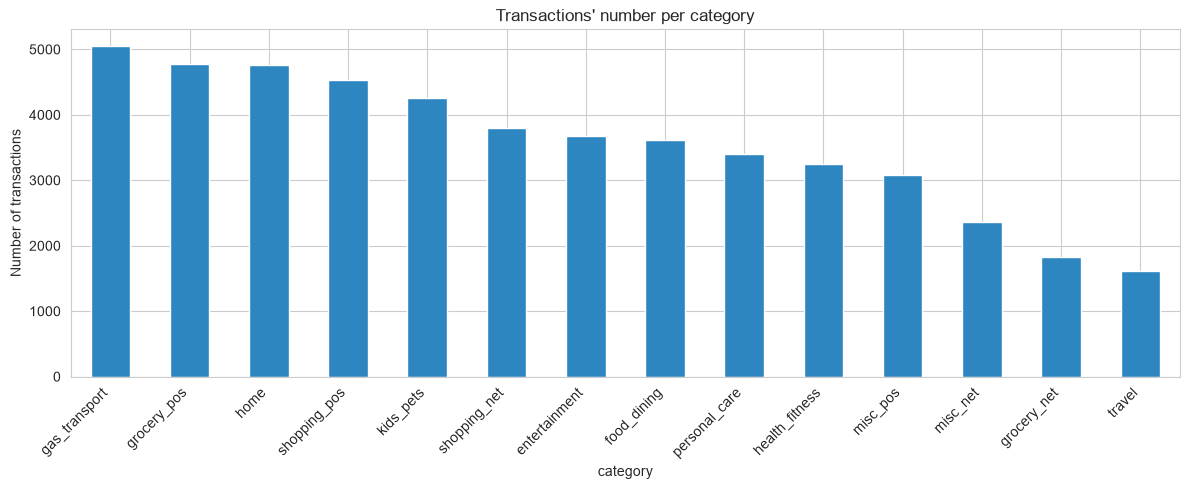

In [32]:
cat_counts=df['category'].value_counts()
print(cat_counts)

plt.figure(figsize=(12, 5)) #12 large 5 haut (alternative : petit = 8,4 grand= 15,8)
cat_counts.plot(kind='bar', color='#2E86C1', edgecolor='white') #edgecolor=contour des barres
#kind = type de graphique bar= barres verticales
#kind='barh'= barres horizontales (mieux quand les labels sont longs)
#kind='line'= courbe
#kind='pie'=camembert
#kind='hist'= histogramme
plt.title("Transactions' number per category")  # titre du graphique
plt.xlabel('category')  # légende axe X
plt.ylabel('Number of transactions')  # légende axe Y
plt.xticks(rotation=45, ha='right')
plt.tight_layout() #Ajuste automatiquement les marges pour que rien ne soit coupé
plt.show()

Here, we observe that categories with the expenditires the most frequent are the gas transport (5,051) and the groceries (4,776). Oddly, the travel occurs at the lest position (1,610) beside the groceries on the web (1,834).

category
grocery_pos     118.358344
shopping_net     96.757754
travel           94.171720
Name: amt, dtype: float64


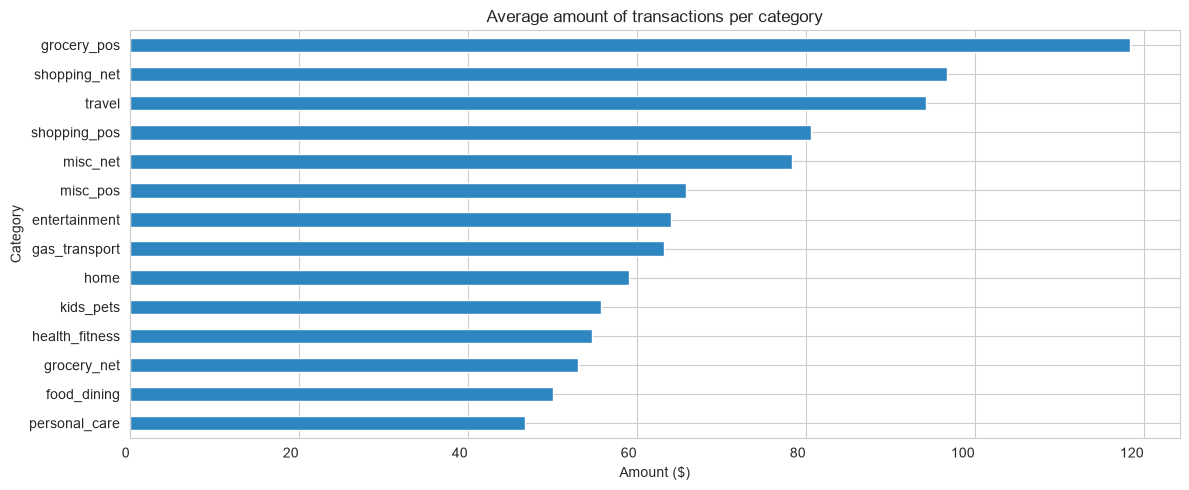

In [33]:
avg_by_cats = df.groupby('category')['amt'].mean()
avg_by_cats = avg_by_cats.sort_values(ascending=True)
print(avg_by_cats.sort_values(ascending=False).head(3))

plt.figure(figsize=(12, 5)) #12 large 5 haut (alternative : petit = 8,4 grand= 15,8)
avg_by_cats.plot(kind='barh', color='#2E86C1', edgecolor='white') #edgecolor=contour des barres
#kind = type de graphique bar= barres verticales
#kind='barh'= barres horizontales (mieux quand les labels sont longs)
#kind='line'= courbe
#kind='pie'=camembert
#kind='hist'= histogramme
plt.title("Average amount of transactions per category")  # titre du graphique
plt.xlabel('Amount ($)')  # légende axe X
plt.ylabel('Category')  # légende axe Y
plt.xticks(rotation=0, ha='right')
plt.tight_layout() #Ajuste automatiquement les marges pour que rien ne soit coupé
plt.show()



We notice that the travel category which was at the lastest position seats at the first for the average amount spent. Therefore, the categories with the most transactions are not those with the highest average amount. However, a key point, the groceries represent the second highest number of transaction but also the highest average amount.

## 4- Demographics analysis 

**Do the spending vary by the gender and the profession ?**

        Average amount ($)  Nb transactions  Total spent ($)
gender                                                      
F                    70.26            27540       1935045.85
M                    70.82            22460       1590648.82


C:\Users\rosea\AppData\Local\Temp\ipykernel_17428\3545445060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='amt', palette=['#2E86C1', 'pink'])


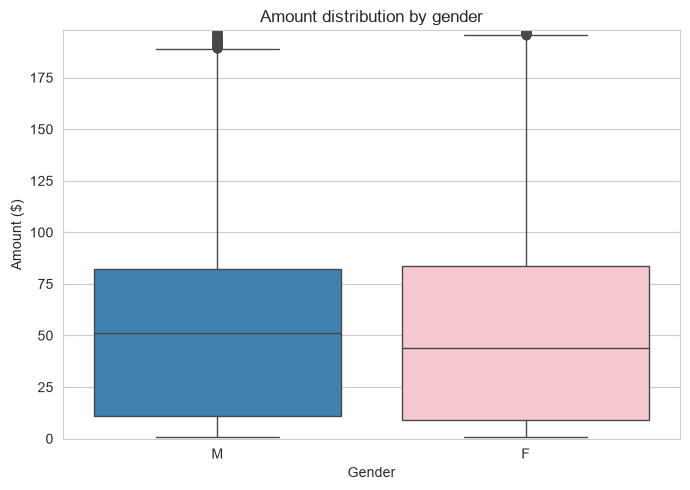

In [34]:
avg_by_gender = df.groupby('gender')['amt'].agg(['mean', 'count', 'sum']).round(2)
avg_by_gender.columns = ['Average amount ($)', 'Nb transactions', 'Total spent ($)']
print(avg_by_gender)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='gender', y='amt', palette=['#2E86C1', 'pink'])
plt.title("Amount distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Amount ($)")
plt.ylim(0, df['amt'].quantile(0.95))  # retire les valeurs extrêmes pour la lisibilité
plt.tight_layout()
plt.show()

Contrary at what we could think, we note that there is not a huge difference between the men's and women's average spending. They are both close to 70$ (70.26$ for the women and 70.82$ for the men)
 Nevertheless, we see that the men's median is more important than the women's, approximatively 51-52$ for the men against approximatively 45$ for the women.
 Which suggests that the women's expanditures are more steady than men's.

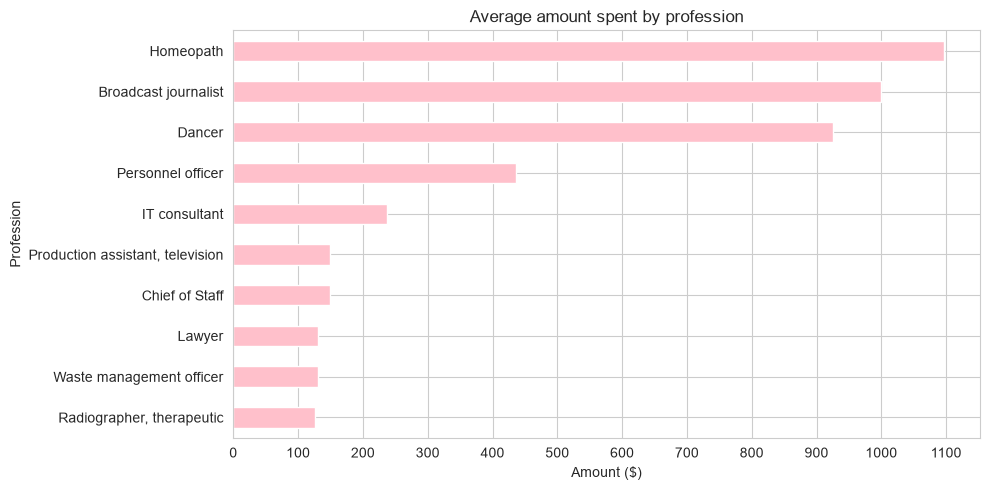

In [35]:
TOP_job = df.groupby('job')['amt'].mean().sort_values(ascending=False).head(10)
TOP10_job=TOP_job.sort_values(ascending=True)
plt.figure(figsize=(10, 5))
TOP10_job.plot(kind='barh', color='pink', edgecolor='white')
plt.title("Average amount spent by profession")
plt.xlabel("Amount ($)")
plt.ylabel("Profession")
plt.xticks(range(0,1200,100))

plt.tight_layout()
plt.show()

We can note that the top 10 of the highest amount spent by profession is very irregular. Indeed, the top 3 : Homeopath (the highest amount spent : aproximatively 1,100$), Broadcast journalist (1,000$) and the Dancer (930$) does not fall below 900$. However, the 4th, which is the personnel officer spent approximatively 440$. We can observe a huge difference between the top 3 and the others suggesting a big difference in the wage therefore in the spending habits too.

## 5- Time analysis

**At which moment of the day and the week the spending are the most frequent ?**

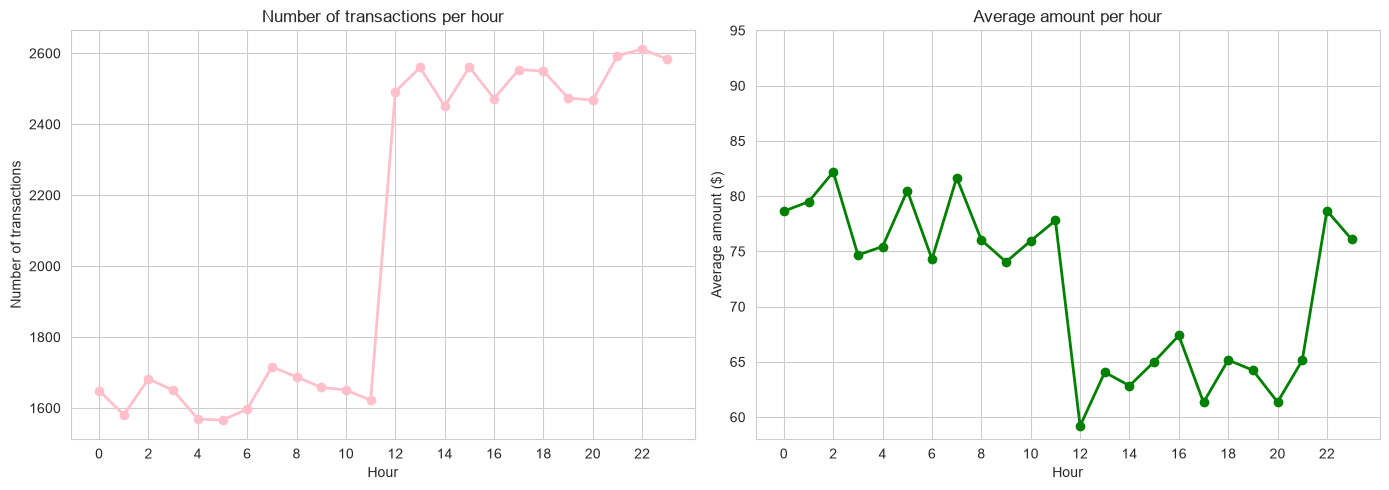

In [36]:
transactions_per_hour = df.groupby('hour')['amt'].agg(['count','mean'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 — gauche
transactions_per_hour['count'].plot(ax=ax1, kind='line', marker='o', color='pink', linewidth=2)
ax1.set_title('Number of transactions per hour')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Number of transactions')
ax1.set_xticks(range(0, 24, 2))

# Graphique 2 — droite
transactions_per_hour['mean'].plot(ax=ax2, kind='line', marker='o', color='green', linewidth=2)
ax2.set_title('Average amount per hour')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Average amount ($)')
ax2.set_xticks(range(0, 24, 2))
ax2.set_yticks(range(60, 100, 5))

plt.tight_layout()
plt.show()

We can see that between midnight and 11 AM there are few transactions,no hour exceed 1,700 transactions and a local peak at 7 AM. However, at 12PM, activity rises and reaches 2,500 transactions.
 The daily peak occurs at 10PM with approximatly 2,600 transactions. Moreover, in the afternoon, transaction volumes never fall below 2,450 transactions per hour, confirming that this is the busiest period of the day alongside the evening peak


Like we have seen for the categories, the hours which have the highest number of transaction are not those with the highest average amounts. In fact, between 12 PM and 9 PM, when transactions volume are at their peak, the amounts of transaction are at their lowest, not exceeding 67$. However, between 10 PM and 11 AM, when fewer transactions occur, average amounts never falls below 74$. The peak is reached at 2AM and 7 AM with 83$. This suggests that daytime transactions tend to be frequent but small (everyday purchases), while late-night and early-morning transactions are rarer but of higher value.

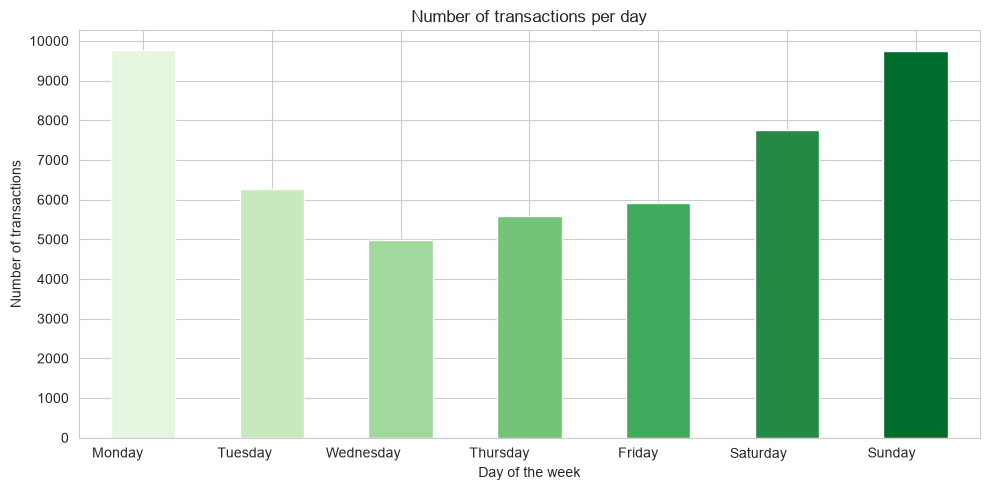

day_of_week
Monday       9774
Tuesday      6261
Wednesday    4990
Thursday     5582
Friday       5903
Saturday     7756
Sunday       9734
Name: amt, dtype: int64


In [37]:
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = sns.color_palette("Greens", 7)

transactions_per_day = df.groupby('day_of_week')['amt'].count().reindex(day_order)
plt.figure(figsize=(10, 5))
transactions_per_day.plot(kind='bar', color=colors, edgecolor='white')
#sns.color_palette("pastel", 7)= couleurs douces/claires 
#sns.color_palette("muted", 7) = couleurs atténuées
#sns.color_palette("husl", 7)  = couleurs vives bien espacées
#sns.color_palette("Blues", 7) = dégradé de bleus
#sns.color_palette("Set2", 7)  = palette colorée classique
plt.title('Number of transactions per day')
plt.xlabel('Day of the week')
plt.ylabel('Number of transactions')
plt.xticks(rotation=0, ha='right')
plt.yticks(range(0,11000,1000))
plt.tight_layout()
plt.show()
print(transactions_per_day)



The weekly peak is reached on Monday with 9,774 transactions closely followed by Sunday with 9,734. 
These two days are by far the busiest of the week. Indeed, the others don't exceed 7,756 reached on Saturday. Therefore, we can see that on the first day of the week there are a lot of transactions realised which then drops at 4,990 on Wednesday and increase sharply on Saturday.

## CONCLUSION

This analysis shows us that the categories with the highest number of transactions are not necessarily the categories with the highest amount. Moreover, we have seen the gender has no significant impact on the transaction habits. Nevertheless, we notice that the amount sepending really depend on the profession. Plus, we have observed that the transactions depend on the hour in a day and the day of the week. Indeed, we have seen that most of the transactions occur in the afternoon to the evening and especially on Mondays and the weekend. Nevertheless, we have seen that the hours with the highest amount spent was not those with the most transactions like the categories.